In [ ]:
# --- mount the dataset from drive
import os
from google.colab import drive

if not os.path.ismount('/content/drive'):
    drive.mount('/content/drive')

if not os.path.isdir('/content/doppler_traces'):
    !unzip "/content/drive/MyDrive/DATASET_SHARP/doppler_traces.zip"

## UTILITY

In [ ]:
import glob
import os
import numpy as np
import pickle
import math as mt
import shutil

def convert_to_number(lab, csi_label_dict):
    lab_num = np.argwhere(np.asarray(csi_label_dict) == lab)[0][0]
    return lab_num


def create_windows(csi_list, labels_list, sample_length, stride_length):
    csi_matrix_stride = []
    labels_stride = []
    for i in range(len(labels_list)):
        csi_i = csi_list[i]
        label_i = labels_list[i]
        len_csi = csi_i.shape[1]
        for ii in range(0, len_csi - sample_length, stride_length):
            csi_matrix_stride.append(csi_i[:, ii:ii+sample_length])
            labels_stride.append(label_i)
    return csi_matrix_stride, labels_stride

def create_windows_antennas(csi_list, labels_list, sample_length, stride_length, remove_mean=False):
    # -------------------------------------------------------------------------------------
    #  Split each activity into windows (keeping all antennas together)
    csi_matrix_stride = []
    labels_stride = []
    for i in range(len(labels_list)):        # iterate over the N ACTIVITIES
        csi_i = csi_list[i]                  # Doppler spectrum (all antennas) of activity i
        label_i = labels_list[i]             # its label (a single value)
        len_csi = csi_i.shape[2]             # time length = number of available Doppler columns
        # Sliding window: starts at 0, advances by stride_length, stops when
        # there is no more room for a full window of sample_length columns.
        for ii in range(0, len_csi - sample_length, stride_length):
            csi_wind = csi_i[:, :, ii:ii + sample_length, ...]   # crop [ii, ii+sample_length)
            if remove_mean:
                # Optional normalization: mean over time (axis 2) and subtraction
                # -> removes the window's constant offset (here it is False by default).
                csi_mean = np.mean(csi_wind, axis=2, keepdims=True)
                csi_wind = csi_wind - csi_mean
            csi_matrix_stride.append(csi_wind)   # +1 sample (one window)
            labels_stride.append(label_i)        # +1 label = the one of activity i
    return csi_matrix_stride, labels_stride

## GENERATE DATASET 

In [3]:
# =====================================================================================
#  DATASET GENERATION (single train/test method)
#  Refactoring of CSI_doppler_create_dataset_train.py and _test.py into ONE function.
#  The `complete` parameter selects the behavior:
#    * complete=False -> like CSI_doppler_create_dataset_train.py:
#                        temporal 60/20/20 split per activity -> train/val/test folders
#    * complete=True  -> like CSI_doppler_create_dataset_test.py:
#                        NO split, the whole sequence -> single "complete" folder
# =====================================================================================

def generate_dataset(data_dir, list_subdir, num_packets, sliding, window_length,
                   stride_length, labels_activities, n_tot, complete=False):
    """
    data_dir         : root folder of the data (Doppler spectra)
    list_subdir      : experiment subfolders, comma-separated (e.g. "S1a,S1b,S1c")
    num_packets      : n. of Wi-Fi packets used for one STFT (e.g. 31)
    sliding          : step (in packets) between two consecutive STFTs
    window_length    : n. of Doppler columns per window (network input, e.g. 340)
    stride_length    : step between two consecutive windows
    labels_activities: activities considered, e.g. "E,J,L,R,W" (the index becomes the label)
    n_tot            : n. of spatial streams * n. of antennas (channels per activity, e.g. 4)
    complete         : False -> train/val/test split ; True -> single "complete" set
    """
    # --- Label dictionary: from "E,J,L,R,W" to a list; the index = numeric label -------
    csi_label_dict = []
    for lab_act in labels_activities.split(','):
        csi_label_dict.append(lab_act)
    # String used only to build the names of output folders/files.
    activities = np.asarray(labels_activities)

    # ==================================================================================
    #  MAIN LOOP: one subfolder (one experiment) at a time
    # ==================================================================================
    for subdir in list_subdir.split(','):
        exp_dir = data_dir + subdir + '/'  # full path of the experiment folder

        # Output folder names
        path_train = exp_dir + 'train_antennas_' + str(activities)
        path_val = exp_dir + 'val_antennas_' + str(activities)
        path_test = exp_dir + 'test_antennas_' + str(activities)
        path_complete = exp_dir + 'complete_antennas_' + str(activities)

        # --- Folder preparation (different logic in the two modes) --------------------
        if not complete:
            # TRAIN MODE: prepare train/val/test (empty them if they exist, else create)
            for pat in [path_train, path_val, path_test]:
                if os.path.exists(pat):
                    for f in glob.glob(pat + '/*'):
                        os.remove(f)
                else:
                    os.mkdir(pat)
            # remove any "complete" from previous runs
            if os.path.exists(path_complete):
                shutil.rmtree(path_complete)
        else:
            # TEST MODE: fully delete train/val/test and prepare "complete"
            # NB: mirrors the original script -> do not generate 'complete' on the same
            #     subdir used for training, or you would erase its split.
            for pat in [path_train, path_val, path_test]:
                if os.path.exists(pat):
                    shutil.rmtree(pat)
            if os.path.exists(path_complete):
                for f in glob.glob(path_complete + '/*'):
                    os.remove(f)
            else:
                os.mkdir(path_complete)

        # --- Input file collection (common to both modes) ----------------------------
        # Files starting with 'S', without extension (.txt), SORTED: this way the n_tot
        # antennas of the same activity end up consecutive.
        names = []
        all_files = os.listdir(exp_dir)
        for i in range(len(all_files)):
            if all_files[i].startswith('S'):
                names.append(all_files[i][:-4])
        names.sort()

        # --- Grouping by activity (common to both modes) -----------------------------
        # Each activity = n_tot consecutive files (one per antenna). Accumulate into
        # 'csi_matrix' and, when complete, pack into 'csi_matrices' with the label.
        csi_matrices = []   # list of arrays (n_tot, doppler_freq, time) -> one per activity
        labels = []         # numeric label of each activity
        lengths = []        # temporal duration (n. of Doppler columns) of each activity
        label = 'null'
        prev_label = label
        csi_matrix = []     # buffer: the antennas of the current activity
        processed = False
        for i_name, name in enumerate(names):
            # At every multiple of n_tot (except the first) an antenna group is complete.
            if i_name % n_tot == 0 and i_name != 0 and processed:
                ll = csi_matrix[0].shape[1]
                for i_ant in range(1, n_tot):
                    if ll != csi_matrix[i_ant].shape[1]:
                        break
                lengths.append(ll)
                csi_matrices.append(np.asarray(csi_matrix))  # stack -> (n_tot, freq, time)
                labels.append(label)
                csi_matrix = []

            label = name[4]  # the label = 5th character of the file name
            if label not in csi_label_dict:
                processed = False
                continue
            processed = True
            print(name)

            label = convert_to_number(label, csi_label_dict)
            if i_name % n_tot == 0:
                prev_label = label
            elif label != prev_label:
                print('error in ' + str(name))
                break

            # Load the Doppler spectrum of the single antenna and remove the per-column mean.
            name_file = exp_dir + name + '.txt'
            with open(name_file, "rb") as fp:
                stft_sum_1 = pickle.load(fp)
            stft_sum_1_mean = stft_sum_1 - np.mean(stft_sum_1, axis=0, keepdims=True)
            csi_matrix.append(stft_sum_1_mean.T)  # -> (doppler_freq, time)

        # --- Closing of the LAST group (common to both modes) -------------------------
        error = False
        if processed:
            if len(csi_matrix) < n_tot:
                print('error in ' + str(name))
            ll = csi_matrix[0].shape[1]
            for i_ant in range(1, n_tot):
                if ll != csi_matrix[i_ant].shape[1]:
                    print('error in ' + str(name))
                    error = True
            if not error:
                lengths.append(ll)
                csi_matrices.append(np.asarray(csi_matrix))
                labels.append(label)

        if error:
            continue

        # ==============================================================================
        #  DISPATCH: split (train) or whole sequence (complete)
        # ==============================================================================
        if not complete:
            # ----- TRAIN MODE: temporal 60/20/20 split per activity -------------------
            lengths = np.asarray(lengths)
            csi_train, csi_val, csi_test = [], [], []
            length_train, length_val, length_test = [], [], []
            for i in range(len(labels)):
                ll = lengths[i]
                # TRAIN: first 60%
                train_len = int(np.floor(ll * 0.6))
                length_train.append(train_len)
                csi_train.append(csi_matrices[i][:, :, :train_len])
                # VAL: next 20%, with a ceil(num_packets/sliding) gap to avoid overlap
                start_val = train_len + mt.ceil(num_packets / sliding)
                val_len = int(np.floor(ll * 0.2))
                length_val.append(val_len)
                csi_val.append(csi_matrices[i][:, :, start_val:start_val + val_len])
                # TEST: remainder, after another gap
                start_test = start_val + val_len + mt.ceil(num_packets / sliding)
                length_test.append(ll - val_len - train_len - 2 * mt.ceil(num_packets / sliding))
                csi_test.append(csi_matrices[i][:, :, start_test:])

            list_sets_name = ['train', 'val', 'test']
            list_sets = [csi_train, csi_val, csi_test]
            list_sets_lengths = [length_train, length_val, length_test]

            # Windowing + saving for each of the 3 sets
            for set_idx in range(3):
                csi_matrices_set, labels_set = create_windows_antennas(
                    list_sets[set_idx], labels, window_length, stride_length, remove_mean=False)
                num_windows = np.floor(
                    (np.asarray(list_sets_lengths[set_idx]) - window_length) / stride_length + 1)
                if not len(csi_matrices_set) == np.sum(num_windows):
                    print('ERROR - shapes mismatch')
                _save_windows(exp_dir, list_sets_name[set_idx], str(activities),
                                csi_matrices_set, labels_set, num_windows)
        else:
            # ----- TEST MODE: no split, the whole sequence -> "complete" --------------
            csi_complete = [csi_matrices[i] for i in range(len(labels))]
            csi_matrices_wind, labels_wind = create_windows_antennas(
                csi_complete, labels, window_length, stride_length, remove_mean=False)
            num_windows = np.floor((np.asarray(lengths) - window_length) / stride_length + 1)
            if not len(csi_matrices_wind) == np.sum(num_windows):
                print('ERROR - shapes mismatch')
            _save_windows(exp_dir, 'complete', str(activities),
                            csi_matrices_wind, labels_wind, num_windows)


def _save_windows(exp_dir, set_name, activities_str, csi_windows, labels_windows, num_windows):
    """Save the windows of a set + the summary files (labels_/files_/num_windows_)."""
    suffix = '.txt'
    names_set = []
    for ii in range(len(csi_windows)):
        name_file = exp_dir + set_name + '_antennas_' + activities_str + '/' + str(ii) + suffix
        names_set.append(name_file)
        with open(name_file, "wb") as fp:            # one window per file (pickle)
            pickle.dump(csi_windows[ii], fp)
    # labels_*: label of each window
    with open(exp_dir + '/labels_' + set_name + '_antennas_' + activities_str + suffix, "wb") as fp:
        pickle.dump(labels_windows, fp)
    # files_*: paths of the saved windows (used by the loader)
    with open(exp_dir + '/files_' + set_name + '_antennas_' + activities_str + suffix, "wb") as fp:
        pickle.dump(names_set, fp)
    # num_windows_*: n. of windows per activity (to reconstruct the antenna groups)
    with open(exp_dir + '/num_windows_' + set_name + '_antennas_' + activities_str + suffix, "wb") as fp:
        pickle.dump(num_windows, fp)


# =====================================================================================
#  PARAMETERS + CALL (for now in NON complete mode -> train/val/test split)
# =====================================================================================
data_dir = '/content/doppler_traces/'   # root folder of the data (dataset unpacked on Colab)
# Tutte le sottocartelle disponibili (numero = set SHARP, lettera = cattura stessa persona/ambiente).
list_subdir = 'S1a,S1b,S1c,S2a,S2b,S3a,S4a,S4b,S5a,S6a,S6b,S7a'
num_packets = 31                        # n. of Wi-Fi packets per STFT
sliding = 1                             # step (in packets) between two STFTs
window_length = 340                     # n. of Doppler columns per window (network input)
stride_length = 30                       # stride finestre: 30 per fine-tune/eval (piu' finestre)
labels_activities = 'E,J,L,R,W'         # activities (the index = label: E->0, J->1, ...)
n_tot = 4                               # n. of streams * n. of antennas

# =====================================================================================
#  CONTROLLO: genera SOLO se il dataset non e' gia presente (evita rigenerazioni lunghe).
#  Metti FORCE_REGEN=True per forzare la rigenerazione (es. se cambi stride/finestra).
# =====================================================================================
FORCE_REGEN = False


def dataset_exists(data_dir, list_subdir, activities_str, sets=('train', 'val', 'test')):
    """True SOLO se per ogni sottocartella esistono l'indice E le finestre referenziate.
       Cosi' un indice 'stale' (di una generazione interrotta) forza la rigenerazione."""
    for sdir in list_subdir.split(','):
        base = data_dir + sdir + '/'
        for st in sets:
            idx = base + 'files_' + st + '_antennas_' + activities_str + '.txt'
            if not os.path.isfile(idx):
                print(f'  indice mancante: {idx}')
                return False
            try:
                with open(idx, 'rb') as fp:
                    flist = pickle.load(fp)
            except Exception:
                print(f'  indice illeggibile: {idx}')
                return False
            # controllo coerenza: prima e ultima finestra devono esistere davvero
            if len(flist) == 0 or not os.path.isfile(flist[0]) or not os.path.isfile(flist[-1]):
                print(f'  finestre mancanti/incoerenti per {sdir} [{st}] -> rigenero')
                return False
    return True


activities_str = str(np.asarray(labels_activities))   # stesso formato usato nei nomi file
if FORCE_REGEN or not dataset_exists(data_dir, list_subdir, activities_str):
    print('Genero il dataset...')
    generate_dataset(data_dir, list_subdir, num_packets, sliding, window_length,
                     stride_length, labels_activities, n_tot, complete=False)
    print('Dataset generato.')
else:
    print('Dataset gia presente: generazione saltata (FORCE_REGEN=True per rigenerare).')


Dataset gia presente: generazione saltata (FORCE_REGEN=True per rigenerare).


## Data augmentation for contrastive learning
 

In [4]:
import torch
import random
from torchvision import transforms


class ContrastiveTransformations(object):
    # Applica base_transforms n_views volte -> lista di viste augmentate della STESSA finestra.
    def __init__(self, base_transforms, n_views=1):
        self.base_transforms = base_transforms
        self.n_views = n_views

    def __call__(self, x):
        return [self.base_transforms(x) for i in range(self.n_views)]


# =====================================================================================
#  AUGMENTATION PER SINGOLA ANTENNA (spettrogramma Doppler)
#  Input atteso: tensor float (1, 340, 100) = (canale, TEMPO, DOPPLER/velocita).
#  NB: gli assi NON sono intercambiabili -> niente flip/rotazioni/grayscale/colorjitter.
#      Le trasformazioni classiche da immagine RGB cambierebbero il significato fisico.
# =====================================================================================

class PerSampleStandardize(object):
    # Media 0 / std 1. Pulisce NaN/inf e gestisce finestre quasi-costanti (std~0)
    # per evitare valori enormi -> NaN a valle.
    def __call__(self, x):
        x = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
        std = x.std()
        if std < 1e-6:
            return x - x.mean()
        return (x - x.mean()) / std


class RandomTimeShift(object):
    # Roll circolare sull'asse TEMPO (dim=-2). L'attivita e' quasi-periodica -> shift valido.
    def __init__(self, max_shift=30, p=0.5):
        self.max_shift = max_shift; self.p = p
    def __call__(self, x):
        if random.random() > self.p:
            return x
        s = random.randint(-self.max_shift, self.max_shift)
        return torch.roll(x, shifts=s, dims=-2)


class RandomTimeMask(object):
    # SpecAugment: azzera un blocco contiguo sull'asse TEMPO (dim=-2).
    def __init__(self, max_width=40, p=0.5):
        self.max_width = max_width; self.p = p
    def __call__(self, x):
        if random.random() > self.p:
            return x
        T = x.shape[-2]
        w = random.randint(1, self.max_width)
        t0 = random.randint(0, max(0, T - w))
        x = x.clone(); x[..., t0:t0 + w, :] = 0.0   # 0 = media dopo standardize
        return x


class RandomFreqMask(object):
    # SpecAugment LEGGERO sull'asse DOPPLER (dim=-1).
    # Tienilo piccolo: i bin Doppler = velocita = cuore sia dell'attivita sia dell'identita (gait).
    def __init__(self, max_width=8, p=0.3):
        self.max_width = max_width; self.p = p
    def __call__(self, x):
        if random.random() > self.p:
            return x
        D = x.shape[-1]
        w = random.randint(1, self.max_width)
        d0 = random.randint(0, max(0, D - w))
        x = x.clone(); x[..., :, d0:d0 + w] = 0.0
        return x


class RandomGain(object):
    # Scala moltiplicativa random dell'ampiezza.
    def __init__(self, lo=0.8, hi=1.2, p=0.5):
        self.lo = lo; self.hi = hi; self.p = p
    def __call__(self, x):
        if random.random() > self.p:
            return x
        return x * random.uniform(self.lo, self.hi)


class GaussianNoise(object):
    # Rumore gaussiano additivo (sigma in scala standardizzata).
    def __init__(self, sigma=0.05, p=0.5):
        self.sigma = sigma; self.p = p
    def __call__(self, x):
        if random.random() > self.p:
            return x
        return x + torch.randn_like(x) * self.sigma


# Pipeline: standardize PRIMA (cosi sigma/gain hanno scala nota), poi augmentation.
# RandomErasing (cutout) di torchvision opera su tensor CxHxW -> ok su (1,340,100).
contrast_transforms = transforms.Compose([
    PerSampleStandardize(),                                   # media 0 / std 1
    RandomTimeShift(max_shift=30, p=0.5),                     # shift temporale
    RandomTimeMask(max_width=40, p=0.5),                      # mask temporale
    RandomFreqMask(max_width=8, p=0.3),                       # mask Doppler (leggera)
    RandomGain(lo=0.8, hi=1.2, p=0.5),                        # scala ampiezza
    GaussianNoise(sigma=0.05, p=0.5),                         # rumore additivo
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.1),       # cutout piccole patch
                             ratio=(0.3, 3.3), value=0.0),
])


## Dataset multi-view (4 antenne) + NT-Xent
Ogni finestra genera **4 viste** (una per antenna), augmentate in modo indipendente. Nella NT-Xent multi-view, i **positivi** di ogni vista sono le altre 3 viste della **stessa finestra**; i **negativi** sono tutte le viste delle altre finestre del batch.

In [5]:
# =====================================================================================
#  DATASET CONTRASTIVE MULTI-VIEW (tutte e 4 le antenne come viste)
#  Ogni finestra (pickle = (n_tot, doppler=100, time=340)) -> n_views augmentazioni,
#  UNA PER ANTENNA, ciascuna augmentata in modo INDIPENDENTE.
# =====================================================================================
import pickle
import math as mt
import random
import numpy as np
from torch.utils.data import Dataset, DataLoader


class CSIContrastiveMultiView(Dataset):
    def __init__(self, csi_files, transform, n_views=4):
        self.files = csi_files
        self.transform = transform     # contrast_transforms (per singola antenna)
        self.n_views = n_views         # <= n_tot ; default 4 = tutte le antenne

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        with open(self.files[idx], "rb") as fp:
            matrix_csi = pickle.load(fp)          # (n_tot, 100, 340)
        n_ant = matrix_csi.shape[0]
        # scegli n_views antenne distinte (n_views=4 -> tutte, in ordine casuale)
        ants = random.sample(range(n_ant), self.n_views)
        views = []
        for a in ants:
            m = matrix_csi[a].T                    # (340, 100)  time x doppler
            m = np.ascontiguousarray(m[np.newaxis, ...])   # (1, 340, 100)
            x = torch.from_numpy(m).float()
            views.append(self.transform(x))        # augmentazione INDIPENDENTE per vista
        views = torch.stack(views, dim=0)          # (n_views, 1, 340, 100)
        return views, idx


# --- Config split (set = parte numerica del nome sottocartella) ---------------------
def set_num(subdir):
    # 'S6a' -> 6 ; 'S12b' -> 12
    return int(''.join(c for c in subdir[1:] if c.isdigit()))

subdirs_all = list_subdir.split(',')
# Set tenuto fuori SOLO per il test AR-generalizzazione (persona presente anche altrove).
# DA CONFERMARE con Table 1: scegli un set la cui persona compare in altri set.
heldout_ar_set = 6
subdirs_pretrain = [s for s in subdirs_all if set_num(s) != heldout_ar_set]
print('Sottocartelle pretraining:', subdirs_pretrain)

# --- Caricamento path finestre TRAIN + sottocampionamento NON sovrapposto -----------
#  IMPORTANTE: NIENTE expand_antennas (multi-view legge tutte le antenne da 1 file).
#  Con stride=30 le finestre si sovrappongono -> prendi 1 finestra ogni k per evitare
#  duplicati / falsi negativi (k = ceil(window_length / stride_length)).
csi_act = labels_activities                           # 'E,J,L,R,W'
suffix = '.txt'
labels_considered = np.arange(len(csi_act.split(',')))  # attivita considerate [0..n-1]
k_sub = mt.ceil(window_length / stride_length)         # 340/30 -> 12

contrastive_files = []
for sdir in subdirs_pretrain:
    base = data_dir + sdir + '/'
    with open(base + 'files_train_antennas_' + str(csi_act) + suffix, "rb") as fp:
        files_s = pickle.load(fp)
    with open(base + 'labels_train_antennas_' + str(csi_act) + suffix, "rb") as fp:
        labels_s = pickle.load(fp)
    # filtro attivita + sottocampionamento non-overlap (ogni k-esima finestra)
    files_filt = [f for f, l in zip(files_s, labels_s) if l in labels_considered]
    contrastive_files.extend(files_filt[::k_sub])


def make_contrastive_loader(csi_files, transform, batch_size, n_views=4, shuffle=True):
    ds = CSIContrastiveMultiView(csi_files, transform, n_views=n_views)
    # drop_last=True: NT-Xent vuole batch pieni (numero di negativi costante).
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=2, drop_last=True)


# Filtro di sicurezza: scarta eventuali finestre referenziate ma non presenti su disco.
_before = len(contrastive_files)
contrastive_files = [f for f in contrastive_files if os.path.isfile(f)]
if len(contrastive_files) < _before:
    print(f'ATTENZIONE: {_before - len(contrastive_files)} finestre mancanti filtrate '
          f'(rigenera con FORCE_REGEN=True se molte).')

contrastive_loader = make_contrastive_loader(contrastive_files, contrast_transforms,
                                             batch_size=64, n_views=n_tot, shuffle=True)
print('Finestre per il pretraining (non-overlap):', len(contrastive_files))


Sottocartelle pretraining: ['S1a', 'S1b', 'S1c', 'S2a', 'S2b', 'S3a', 'S4a', 'S4b', 'S5a', 'S7a']
Finestre per il pretraining (non-overlap): 1624


In [6]:
# =====================================================================================
#  NT-Xent MULTI-VIEW (4 antenne come viste della stessa finestra)
#  Generalizzazione multi-positive di NT-Xent (forma InfoNCE/SupCon).
#  Per ogni vista: positivi = le altre viste della STESSA finestra; negativi = tutte
#  le viste delle ALTRE finestre del batch.
# =====================================================================================
import torch
import torch.nn.functional as F


def nt_xent_multiview(z, n_views, temperature=0.2):
    """
    z : (N * n_views, D) embeddings dal projection head.
        LAYOUT atteso: le n_views di una stessa finestra sono CONSECUTIVE
        (finestra 0 -> righe 0..n_views-1, finestra 1 -> righe n_views..2*n_views-1, ...).
        Si ottiene con views.view(N*n_views, 1, 340, 100) prima del forward.
    """
    M = z.size(0)                       # N * n_views
    N = M // n_views
    device = z.device

    z = F.normalize(z, dim=1)           # embedding su ipersfera unitaria
    sim = (z @ z.t()) / temperature     # (M, M) similarita coseno / temperatura

    # id finestra per ogni riga: [0,0,0,0, 1,1,1,1, ...] con n_views ripetizioni
    group = torch.arange(N, device=device).repeat_interleave(n_views)   # (M,)
    self_mask = torch.eye(M, dtype=torch.bool, device=device)
    pos_mask = (group[:, None] == group[None, :]) & ~self_mask          # positivi (no self)

    # denominatore InfoNCE = softmax su tutte le colonne tranne se stesso
    sim = sim.masked_fill(self_mask, float('-inf'))
    log_prob = sim - torch.logsumexp(sim, dim=1, keepdim=True)

    # media della log-prob sui positivi (multi-positive InfoNCE / SupCon)
    pos_per_row = pos_mask.sum(1).clamp(min=1)
    # NB: log_prob ha -inf sulla diagonale (self mascherato). log_prob*pos_mask darebbe
    #     -inf*0 = NaN. torch.where prende log_prob solo sui positivi (finiti), 0 altrove.
    log_prob_pos = torch.where(pos_mask, log_prob, torch.zeros_like(log_prob))
    loss = -log_prob_pos.sum(1) / pos_per_row
    return loss.mean()


# --- Esempio di uso in un training step (backbone + projection head da definire dopo) --
# for views, _ in contrastive_loader:          # views: (N, n_views, 1, 340, 100)
#     N, V = views.shape[0], views.shape[1]
#     views = views.view(N * V, 1, 340, 100).to(device)   # layout consecutivo per finestra
#     z = projection_head(backbone(views))                # (N*V, D)
#     loss = nt_xent_multiview(z, n_views=V, temperature=0.2)
#     loss.backward(); optimizer.step(); optimizer.zero_grad()


## NEURAL NETWORK — CSI_network (PyTorch)
PyTorch porting of `CSI_network.py` + `network_utility.py` + `dataset_utility.py` (single-antenna loader). The points where we switch from TensorFlow/Keras to PyTorch are marked with `>>> CHANGE`.

In [7]:
# =====================================================================================
#  NEURAL NETWORK — porting of network_utility.py (Keras) to PyTorch
#  "inception-residual" single-antenna architecture (csi_network_inc_res).
#  >>> CHANGE TF->PyTorch: Keras uses channels-LAST (N,H,W,C); PyTorch channels-FIRST
#      (N,C,H,W). The network input goes from (340,100,1) [Keras] to (1,340,100) [PyTorch].
# =====================================================================================
import torch
import torch.nn as nn
import torch.nn.functional as F


class ConvBnRelu(nn.Module):
    """
    Porting of conv2d_bn: in the original it was Conv2D + (optional BatchNorm) + ReLU.
    NB: in the SHARP model bn=False always -> here it is just Conv2d + ReLU.
    >>> CHANGE: tf.keras.layers.Conv2D -> nn.Conv2d (channels first).
    """
    def __init__(self, in_ch, out_ch, kernel_size, stride=1, padding='same', activation=True, batchNormalization = False):
        super().__init__()
        # Keras 'same': in PyTorch supported ONLY with stride=1. For the convs with
        # stride=2 we pass an integer padding computed by hand (see ReductionABlockSmall).
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size, stride=stride, padding=padding)
        self.bn = nn.BatchNorm2d(out_ch)
        self.batchNormalization = batchNormalization
        self.activation = activation

    def forward(self, x):
        x = self.conv(x)
        if self.batchNormalization:
            x = self.bn(x)
        if self.activation:
            x = F.relu(x)   # >>> CHANGE: Activation('relu') -> F.relu
        return x


class ReductionABlockSmall(nn.Module):
    """
    Porting of reduction_a_block_small: 3 parallel branches concatenated over channels.
    Input (N,1,340,100) -> output (N,15,170,50).
    """
    def __init__(self, in_ch):
        super().__init__()
        # Branch 1: MaxPool 2x2 stride 2 (padding 'valid'=0) -> halves H,W, 1 channel.
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        # Branch 2: Conv 5 filters 2x2 stride 2 padding 'valid'(=0) -> (N,5,170,50).
        self.b2 = ConvBnRelu(in_ch, 5, kernel_size=2, stride=2, padding=0)
        # Branch 3: 1x1 same -> 2x2 same -> 4x4 stride2.
        self.b3_1 = ConvBnRelu(in_ch, 3, kernel_size=1, stride=1, padding='same')
        self.b3_2 = ConvBnRelu(3, 6, kernel_size=2, stride=1, padding='same')
        # >>> CHANGE: TF's 4x4 stride2 'same' conv -> padding=1. TF's 'same' here
        #     requires total padding = 2 (symmetric), so padding=1 replicates
        #     EXACTLY the TensorFlow 170x50 output ('same' not usable with stride 2).
        self.b3_3 = ConvBnRelu(6, 9, kernel_size=4, stride=2, padding=1)

    def forward(self, x):
        x1 = self.pool(x)          # (N,1,170,50)
        x2 = self.b2(x)            # (N,5,170,50)
        x3 = self.b3_1(x)
        x3 = self.b3_2(x3)
        x3 = self.b3_3(x3)         # (N,9,170,50)
        # >>> CHANGE: Concatenate (trailing channels axis in Keras) -> torch.cat(dim=1).
        return torch.cat([x1, x2, x3], dim=1)   # (N,15,170,50)


# CONTRASTIVE PRETRAINING + 2 TESTE (AR + PI)
Pipeline: **pretraining self-supervised** (NT-Xent multi-view, 4 antenne) di una backbone condivisa, poi **fine-tuning a 2 teste** (AR = attività, PI = persona).
Due backbone a confronto: **Inception** (`CSINetworkIncRes` riusata) e **ResNet18** (Lab 8, adattata a 1 canale).

In [8]:
# =====================================================================================
#  SETUP INDIPENDENTE — parametri usati dalla sezione contrastive.
#  Cosi' NON serve rieseguire la cella di training supervisionato (c6770efa).
#  (window_length, labels_activities, n_tot, data_dir provengono dalla cella di generazione)
# =====================================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
sample_length = window_length                       # 340 (asse tempo)
feature_length = 100                                # 100 (asse Doppler)
output_shape = len(labels_activities.split(','))    # n. attivita (E,J,L,R,W -> 5)

Device: cuda


In [9]:
# =====================================================================================
#  BACKBONE COMUNI — interfaccia unica: attributo .feature_dim + forward(x)->(N, feature_dim)
#  Entrambe proiettano a un embedding COMUNE (EMBED_DIM), cosi' il confronto e' equo e
#  l'embedding e' piccolo (niente flatten da 25500). Riusa ReductionABlockSmall / ConvBnRelu.
# =====================================================================================
import torchvision

EMBED_DIM = 256    # dimensione embedding condivisa dalle 2 backbone


class InceptionEncoder(nn.Module):
    """Backbone SHARP senza testa densa: reduction -> 1x1 conv -> Global Avg Pool -> EMBED_DIM.
       Sostituisce il flatten enorme (25500) con GAP -> embedding compatto."""
    def __init__(self, input_channels=1, embed_dim=EMBED_DIM):
        super().__init__()
        self.reduction = ReductionABlockSmall(input_channels)                 # -> (15, H/2, W/2)
        self.proj_conv = ConvBnRelu(15, embed_dim, kernel_size=1, stride=1, padding='same')
        self.pool = nn.AdaptiveAvgPool2d(1)                                   # -> (embed_dim, 1, 1)
        self.feature_dim = embed_dim

    def forward(self, x):
        x = self.reduction(x)
        x = self.proj_conv(x)
        x = self.pool(x)
        return torch.flatten(x, start_dim=1)                                 # (N, embed_dim)


class ResNetEncoder(nn.Module):
    """ResNet18 (Lab 8) adattata a input 1-canale; fc -> proiezione a EMBED_DIM."""
    def __init__(self, input_channels=1, embed_dim=EMBED_DIM):
        super().__init__()
        net = torchvision.models.resnet34(weights=None)
        # patch conv1: da 3 canali (RGB) a 1 canale (spettrogramma Doppler)
        net.conv1 = nn.Conv2d(input_channels, 64, kernel_size=7, stride=2, padding=3, bias=False)
        # fc: da testa di classificazione a proiezione 512 -> embed_dim
        net.fc = nn.Linear(net.fc.in_features, embed_dim)
        self.net = net
        self.feature_dim = embed_dim

    def forward(self, x):
        return self.net(x)                                                   # (N, embed_dim)


# Sanity check delle shape (istanzia UNA volta ciascuna; usa sample_length/feature_length).
_inc, _res = InceptionEncoder(), ResNetEncoder()
_dummy = torch.zeros(2, 1, sample_length, feature_length)
print('InceptionEncoder feature_dim:', _inc.feature_dim, '| out:', tuple(_inc(_dummy).shape))
print('ResNetEncoder    feature_dim:', _res.feature_dim, '| out:', tuple(_res(_dummy).shape))

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/conv.py:548: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1024.)
  return F.conv2d(


InceptionEncoder feature_dim: 256 | out: (2, 256)
ResNetEncoder    feature_dim: 256 | out: (2, 256)


In [10]:
# =====================================================================================
#  PROJECTION HEAD + ContrastiveNet (pattern SimCLR / Lab 8)
#  La projection head si usa SOLO in pretraining; poi si tiene la sola backbone.
# =====================================================================================
class ProjectionHead(nn.Module):
    def __init__(self, in_dim, hidden_dim=512, proj_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, proj_dim),
        )

    def forward(self, x):
        return self.net(x)


class ContrastiveNet(nn.Module):
    def __init__(self, encoder, hidden_dim=512, proj_dim=128):
        super().__init__()
        self.encoder = encoder
        self.projection = ProjectionHead(encoder.feature_dim, hidden_dim, proj_dim)

    def forward(self, x):
        return self.projection(self.encoder(x))       # (N, proj_dim)

In [11]:
# =====================================================================================
#  LOOP PRETRAINING CONTRASTIVE (NT-Xent multi-view) — con MIXED PRECISION (AMP)
#  AdamW + CosineAnnealingLR (Lab 8). Checkpoint resumable (Colab-friendly).
#  AMP dimezza la memoria GPU; ritorna la backbone (encoder) allenata.
# =====================================================================================
def pretrain_contrastive(encoder, loader, epochs=100, lr=2e-4, weight_decay=1e-4,
                         temperature=0.15, hidden_dim=512, proj_dim=128,
                         ckpt_name='contrastive.torch', device=device):
    torch.cuda.empty_cache()
    model = ContrastiveNet(encoder, hidden_dim, proj_dim).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=lr / 50)
    use_amp = False   # AMP off: Inception senza BatchNorm -> fp16 puo' overfloware (NaN)
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)   # API nuova (non deprecata)

    start_epoch = 0
    if os.path.exists(ckpt_name):                       # RESUME (Colab interrompe le sessioni)
        ck = torch.load(ckpt_name, map_location=device)
        model.load_state_dict(ck['model_state_dict'])
        optimizer.load_state_dict(ck['optimizer_state_dict'])
        scheduler.load_state_dict(ck['scheduler_state_dict'])
        if 'scaler_state_dict' in ck:
            scaler.load_state_dict(ck['scaler_state_dict'])
        start_epoch = ck['epoch'] + 1
        print(f'Resume {ckpt_name} da epoch {start_epoch}')

    for epoch in range(start_epoch, epochs):
        model.train()
        losses, n_bad = [], 0
        for views, _ in loader:                        # views: (N, V, 1, 340, 100)
            N, V = views.shape[0], views.shape[1]
            # view(N*V, ...): le V viste di una finestra restano CONSECUTIVE (richiesto da nt_xent_multiview)
            x = views.view(N * V, 1, sample_length, feature_length).to(device)
            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=use_amp):
                z = model(x)                           # (N*V, proj_dim)
            loss = nt_xent_multiview(z.float(), n_views=V, temperature=temperature)  # loss in fp32 (stabile)
            if not torch.isfinite(loss):    # guardia: non corrompere i pesi con NaN/inf
                n_bad += 1
                continue
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            losses.append(loss.item())
        scheduler.step()
        mean_loss = float(np.mean(losses)) if losses else float('nan')
        msg = f'[{ckpt_name}] Epoch {epoch + 1}/{epochs} - contrastive_loss={mean_loss:.4f}'
        if n_bad:
            msg += f' (batch scartati non-finiti: {n_bad})'
        print(msg)
        torch.save({'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'scheduler_state_dict': scheduler.state_dict(),
                    'scaler_state_dict': scaler.state_dict()}, ckpt_name)
    return model.encoder


In [12]:
# =====================================================================================
#  CHECKPOINT DIR SU DRIVE (persistente -> resume automatico dopo disconnessione Colab)
# =====================================================================================
import os

# Solo Drive: sopravvive al drop della sessione Colab -> pretrain_contrastive riprende
# dall'ultima epoch salvata. Serve aver montato Drive (cella iniziale drive.mount).
assert os.path.isdir('/content/drive/MyDrive'), 'Monta Drive prima (cella iniziale drive.mount)'
CKPT_DIR = '/content/drive/MyDrive/HAR_checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)
print('Checkpoint dir:', CKPT_DIR)

def ckpt_path(name):
    # path completo di un checkpoint nella dir persistente su Drive
    return os.path.join(CKPT_DIR, name)


Checkpoint dir: /content/drive/MyDrive/HAR_checkpoints


In [13]:
# =====================================================================================
#  DRIVER PRETRAINING — backbone ResNet18
# =====================================================================================
PRETRAIN_EPOCHS = 100
CONTRASTIVE_TEMP = 0.15

# --- Backbone: ResNet18 (Lab 8) ---
res_encoder = ResNetEncoder(input_channels=1)
res_backbone = pretrain_contrastive(res_encoder, contrastive_loader,
                                    epochs=PRETRAIN_EPOCHS, temperature=CONTRASTIVE_TEMP,
                                    ckpt_name=ckpt_path('contrastive_resnet.torch'))


Resume /content/drive/MyDrive/HAR_checkpoints/contrastive_resnet.torch da epoch 100


In [14]:
# =====================================================================================
#  LABEL PERSONA (PI) + DATASET 2-TESTE
#  La label attivita esiste gia'; la label PERSONA si deriva dal set (Table 1 del paper).
#  Input single-antenna (come nel main) -> decision fusion a valle. Ritorna (x, y_act, y_person).
# =====================================================================================
import re

# --- Mappa set -> persona (id interi contigui). PLACEHOLDER: correggi da Table 1! -----
#     Noto dal paper: S1,S2 = P1 ; S3 = persona diversa ; S7 = persona nuova.
set_to_person = {1: 0, 2: 0, 3: 1, 4: 0, 5: 1, 6: 0, 7: 2}   # <-- DA VERIFICARE su Table 1

n_act = output_shape                                   # n. attivita (5)
n_persons = len(set(set_to_person[set_num(s)] for s in subdirs_pretrain))
print('n_act:', n_act, '| n_persons (nei set di training):', n_persons)


class CSITwoHeadDataset(Dataset):
    """Single-antenna: ritorna (x, y_activity, y_person)."""
    def __init__(self, files, act_labels, person_labels, stream_ant):
        self.files = files
        self.act = act_labels
        self.person = person_labels
        self.stream_ant = list(stream_ant)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        with open(self.files[idx], "rb") as fp:
            m = pickle.load(fp)                        # (4, 100, 340)
        s = self.stream_ant[idx]
        x = m[s].T                                     # (340, 100)
        x = torch.from_numpy(np.ascontiguousarray(x[np.newaxis, ...])).float()  # (1,340,100)
        y_a = torch.tensor(int(self.act[idx]), dtype=torch.long)
        y_p = torch.tensor(int(self.person[idx]), dtype=torch.long)
        return x, y_a, y_p


def load_split_twohead(subdirs, set_name):
    """Carica un set (train/val/test) su piu' sottocartelle, con label attivita + persona,
       ed espande per antenna (single-antenna input, come nel main)."""
    files_sel, act_sel, per_sel = [], [], []
    for sdir in subdirs:
        base = data_dir + sdir + '/'
        with open(base + 'files_' + set_name + '_antennas_' + str(csi_act) + suffix, "rb") as fp:
            fs = pickle.load(fp)
        with open(base + 'labels_' + set_name + '_antennas_' + str(csi_act) + suffix, "rb") as fp:
            ls = pickle.load(fp)
        p = set_to_person[set_num(sdir)]              # persona del set
        for f, l in zip(fs, ls):
            if l in labels_considered and os.path.isfile(f):
                files_sel.append(f); act_sel.append(l); per_sel.append(p)
    # espansione per antenna: ogni finestra -> n_tot campioni single-antenna
    files_exp = [f for f in files_sel for _ in range(n_tot)]
    act_exp   = [a for a in act_sel   for _ in range(n_tot)]
    per_exp   = [p for p in per_sel   for _ in range(n_tot)]
    stream_ant = np.tile(np.arange(n_tot), len(files_sel))
    return files_exp, act_exp, per_exp, stream_ant


def make_twohead_loader(subdirs, set_name, batch_size=32, shuffle=False):
    fx, ax, px, sa = load_split_twohead(subdirs, set_name)
    ds = CSITwoHeadDataset(fx, ax, px, sa)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, num_workers=2, drop_last=False)


# --- Split per le 2 teste -----------------------------------------------------------
subdirs_heldout = [s for s in subdirs_all if set_num(s) == heldout_ar_set]   # solo AR-gen

ft_train_loader = make_twohead_loader(subdirs_pretrain, 'train', batch_size=32, shuffle=True)
ft_val_loader   = make_twohead_loader(subdirs_pretrain, 'val',   batch_size=32, shuffle=False)
# Test PI + AR within-domain (persone viste, finestre held-out nel tempo):
test_within_loader = make_twohead_loader(subdirs_pretrain, 'test', batch_size=32, shuffle=False)
# Test AR generalizzazione (set held-out, ambiente/giorno nuovi): unione train+val+test del set held-out
ar_gen_loaders = [make_twohead_loader(subdirs_heldout, s, batch_size=32, shuffle=False)
                  for s in ['train', 'val', 'test']]
print('Set held-out per AR-gen:', subdirs_heldout)

n_act: 5 | n_persons (nei set di training): 3
Set held-out per AR-gen: ['S6a', 'S6b']


In [ ]:
# =====================================================================================
#  TwoHeadNet — backbone CONDIVISA + 2 teste MLP (AR e PI)
# =====================================================================================
def make_mlp_head(in_dim, out_dim, hidden_dim=None, p_drop=0.0):
    # MLP head: Linear -> BN -> ReLU -> (Dropout) -> Linear
    hidden_dim = hidden_dim or in_dim                     # default: stessa dim feature
    layers = [
        nn.Linear(in_dim, hidden_dim),
        nn.BatchNorm1d(hidden_dim),
        nn.ReLU(inplace=True),
    ]
    if p_drop > 0:
        layers.append(nn.Dropout(p_drop))                 # regolarizza fine-tune
    layers.append(nn.Linear(hidden_dim, out_dim))
    return nn.Sequential(*layers)

class TwoHeadNet(nn.Module):
    def __init__(self, encoder, n_act, n_persons, hidden_dim=None, p_drop=0.0):
        super().__init__()
        self.encoder = encoder
        self.head_ar = make_mlp_head(encoder.feature_dim, n_act,     hidden_dim, p_drop)   # attivita
        self.head_pi = make_mlp_head(encoder.feature_dim, n_persons, hidden_dim, p_drop)   # persona

    def forward(self, x):
        f = self.encoder(x)
        return self.head_ar(f), self.head_pi(f)                    # (logits_ar, logits_pi)

In [21]:
# =====================================================================================
#  FINE-TUNING 2 TESTE — Fase A linear probe (backbone congelata) + Fase B full fine-tune
#  Loss combinata: L = CE(AR) + lam * CE(PI).
#  CHECKPOINT RESUMABLE su Drive: salva TUTTO il necessario per riprendere
#  (model + optimizer + phase + epoch + best) -> sopravvive al drop di Colab.
# =====================================================================================
def _run_epoch(model, loader, optimizer, ce, lam, train, device, encoder_eval=False):
    if train:
        model.train()
        if encoder_eval:
            model.encoder.eval()          # probe: congela anche i BatchNorm dell'encoder
    else:
        model.eval()
    tot, loss_sum, ca, cp = 0, 0.0, 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, ya, yp in loader:
            x, ya, yp = x.to(device), ya.to(device), yp.to(device)
            la, lp = model(x)
            loss = ce(la, ya) + lam * ce(lp, yp)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            bs = x.size(0); tot += bs; loss_sum += loss.item() * bs
            ca += (la.argmax(1) == ya).sum().item()
            cp += (lp.argmax(1) == yp).sum().item()
    return loss_sum / tot, ca / tot, cp / tot


def finetune_twohead(encoder, train_loader, val_loader, n_act, n_persons, lam=1.0,
                     probe_epochs=15, full_epochs=10, lr_probe=1e-3, lr_full=1e-4,
                     wd=1e-4, ckpt_name='twohead.torch', device=device):
    model = TwoHeadNet(encoder, n_act, n_persons).to(device)
    ce = nn.CrossEntropyLoss()
    best_path = ckpt_name.replace('.torch', '_best.torch')   # solo pesi migliori (per il load finale)

    # ---- stato resumable ----
    phase, start_epoch, best, ck = 'probe', 0, -1.0, None
    if os.path.exists(ckpt_name):                            # RESUME dopo disconnessione Colab
        ck = torch.load(ckpt_name, map_location=device)
        model.load_state_dict(ck['model_state_dict'])
        phase, start_epoch, best = ck['phase'], ck['epoch'], ck['best']
        print(f'Resume {ckpt_name}: phase={phase} epoch={start_epoch} best={best:.3f}')

    def save_ck(cur_phase, next_epoch, opt):
        # checkpoint COMPLETO: tutto il necessario per riprendere il training
        torch.save({'phase': cur_phase, 'epoch': next_epoch, 'best': best,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': opt.state_dict(),
                    'n_act': n_act, 'n_persons': n_persons}, ckpt_name)

    # ---- Fase A: LINEAR PROBE (backbone congelata) ----
    if phase == 'probe':
        for p in model.encoder.parameters():
            p.requires_grad = False
        opt = torch.optim.AdamW([*model.head_ar.parameters(), *model.head_pi.parameters()],
                                lr=lr_probe, weight_decay=1e-3)
        if ck is not None and ck['phase'] == 'probe':
            opt.load_state_dict(ck['optimizer_state_dict'])  # riprendi lo stato optimizer del probe
        for e in range(start_epoch, probe_epochs):
            _run_epoch(model, train_loader, opt, ce, lam, True, device, encoder_eval=True)
            vl = _run_epoch(model, val_loader, opt, ce, lam, False, device)
            print(f'[probe {e + 1}/{probe_epochs}] val_loss={vl[0]:.3f} AR={vl[1]:.3f} PI={vl[2]:.3f}')
            save_ck('probe', e + 1, opt)
        phase, start_epoch, ck = 'full', 0, None             # passa a fase B (optimizer nuovo)

    # ---- Fase B: FULL FINE-TUNE (sblocca backbone, LR piccolo) ----
    for p in model.encoder.parameters():
        p.requires_grad = True
    opt = torch.optim.AdamW(model.parameters(), lr=lr_full, weight_decay=wd)
    if ck is not None and ck['phase'] == 'full':
        opt.load_state_dict(ck['optimizer_state_dict'])      # riprendi lo stato optimizer del full
    for e in range(start_epoch, full_epochs):
        _run_epoch(model, train_loader, opt, ce, lam, True, device)
        vl = _run_epoch(model, val_loader, opt, ce, lam, False, device)
        print(f'[full  {e + 1}/{full_epochs}] val_loss={vl[0]:.3f} AR={vl[1]:.3f} PI={vl[2]:.3f}')
        score = vl[1] + vl[2]                                # media implicita AR+PI
        if score > best:
            best = score
            torch.save(model.state_dict(), best_path)        # tiene i pesi migliori su val
        save_ck('full', e + 1, opt)                          # checkpoint resumable ogni epoch

    if os.path.exists(best_path):                            # carica i pesi migliori su val
        model.load_state_dict(torch.load(best_path, map_location=device))
    return model


# --- Fine-tuning delle 2 backbone (usa le backbone pre-allenate) --------------------

res_model = finetune_twohead(res_backbone, ft_train_loader, ft_val_loader, n_act, n_persons,
                             ckpt_name=ckpt_path('twohead_resnet.torch'))


Resume /content/drive/MyDrive/HAR_checkpoints/twohead_resnet.torch: phase=full epoch=12 best=1.948


In [22]:
# =====================================================================================
#  VALUTAZIONE + DECISION FUSION (per ENTRAMBE le teste AR e PI)
#  Fusione: media dei softmax sulle n_tot antenne della stessa acquisizione.
#  (i campioni sono ordinati a blocchi di n_tot consecutivi -> stessa acquisizione)
# =====================================================================================
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

def predict_two(model, loader, device=device):
    model.eval()
    Pa, Pp, Ya, Yp = [], [], [], []
    with torch.no_grad():
        for x, ya, yp in loader:
            la, lp = model(x.to(device))
            Pa.append(F.softmax(la, 1).cpu().numpy())
            Pp.append(F.softmax(lp, 1).cpu().numpy())
            Ya.append(ya.numpy()); Yp.append(yp.numpy())
    return (np.concatenate(Pa), np.concatenate(Pp),
            np.concatenate(Ya), np.concatenate(Yp))


def _fuse(prob, n=n_tot):
    # media softmax su blocchi di n antenne -> (N_acq, C)
    N = prob.shape[0] // n
    return prob[:N * n].reshape(N, n, -1).mean(1)


def eval_task(prob, y_true, n=n_tot):
    fused = _fuse(prob, n)
    N = fused.shape[0]
    yt = np.asarray(y_true)[:N * n].reshape(N, n)[:, 0]   # 1 label per acquisizione
    yp = fused.argmax(1)
    return accuracy_score(yt, yp), f1_score(yt, yp, average='macro'), confusion_matrix(yt, yp)


def eval_pi_gen(prob, y_true, n_persons, n=n_tot):
    # PI su set held-out: nel dataset il set held-out contiene UNA sola persona (nota).
    # Quindi NON e' un test di discriminazione: e' un check di ROBUSTEZZA cross-dominio
    # (l'ambiente nuovo degrada l'identita' della persona nota?).
    # accuracy = frazione di acquisizioni ancora attribuite alla persona corretta.
    # f1 macro sarebbe fuorviante con 1 sola classe vera -> riportiamo accuracy + distribuzione.
    fused = _fuse(prob, n)
    N = fused.shape[0]
    yt = np.asarray(y_true)[:N * n].reshape(N, n)[:, 0]
    yp = fused.argmax(1)
    acc = accuracy_score(yt, yp)
    persons_true = sorted(set(yt.tolist()))
    pred_counts = {int(k): int((yp == k).sum()) for k in range(n_persons)}
    return acc, persons_true, pred_counts, N


def evaluate_model(name, model):
    # --- Test within-domain (persone viste, finestre held-out nel tempo): AR + PI ---
    Pa, Pp, Ya, Yp = predict_two(model, test_within_loader)
    ar_acc, ar_f1, ar_cm = eval_task(Pa, Ya)
    pi_acc, pi_f1, pi_cm = eval_task(Pp, Yp)
    # --- Generalizzazione su set held-out (ambiente/giorno nuovi): AR + PI ---
    Pa_g, Ya_g, Pp_g, Yp_g = [], [], [], []
    for ld in ar_gen_loaders:
        pa, pp, ya, yp = predict_two(model, ld)
        Pa_g.append(pa); Ya_g.append(ya); Pp_g.append(pp); Yp_g.append(yp)
    arg_acc, arg_f1, _ = eval_task(np.concatenate(Pa_g), np.concatenate(Ya_g))
    # PI-gen: test DEBOLE (set held-out = 1 sola persona nota) -> solo robustezza cross-dominio
    pig_acc, pig_persons, pig_pred, pig_N = eval_pi_gen(
        np.concatenate(Pp_g), np.concatenate(Yp_g), n_persons)
    print(f'==== {name} ====')
    print(f'AR within        acc={ar_acc:.3f}  f1={ar_f1:.3f}')
    print(f'PI within        acc={pi_acc:.3f}  f1={pi_f1:.3f}')
    print(f'AR gen(hold-out) acc={arg_acc:.3f}  f1={arg_f1:.3f}')
    print(f'PI gen(hold-out) acc={pig_acc:.3f}  [TEST DEBOLE: persone presenti={pig_persons}, '
          f'N_acq={pig_N}]')
    print(f'   -> distribuzione predizioni PI-gen per classe: {pig_pred}')
    print('   -> acc = frazione ancora riconosciuta come la persona corretta in ambiente nuovo;')
    print('      NON misura discriminazione tra persone (1 sola classe nel set held-out).')
    print('Confusion AR (within):\n', ar_cm)
    print('Confusion PI (within):\n', pi_cm)
    return dict(AR_within=ar_acc, PI_within=pi_acc, AR_gen=arg_acc, PI_gen=pig_acc,
                AR_f1=ar_f1, PI_f1=pi_f1, ARgen_f1=arg_f1)


res_res = evaluate_model('ResNet', res_model)

# --- Riepilogo metriche ResNet ---
print('\n=== METRICHE ResNet ===')
print(pd.DataFrame([res_res], index=['ResNet']).round(3))


==== ResNet ====
AR within        acc=1.000  f1=1.000
PI within        acc=0.955  f1=0.956
AR gen(hold-out) acc=0.995  f1=0.995
PI gen(hold-out) acc=0.966  [TEST DEBOLE: persone presenti=[0], N_acq=5865]
   -> distribuzione predizioni PI-gen per classe: {0: 5664, 1: 196, 2: 5}
   -> acc = frazione ancora riconosciuta come la persona corretta in ambiente nuovo;
      NON misura discriminazione tra persone (1 sola classe nel set held-out).
Confusion AR (within):
 [[1341    0    0    0    0]
 [   0  822    0    0    0]
 [   0    0 1460    0    0]
 [   0    0    0 1147    0]
 [   0    0    0    0 1132]]
Confusion PI (within):
 [[3961  234    0]
 [  29 1190    0]
 [   0    0  488]]

=== METRICHE ResNet ===
        AR_within  PI_within  AR_gen  PI_gen  AR_f1  PI_f1  ARgen_f1
ResNet        1.0      0.955   0.995   0.966    1.0  0.956     0.995


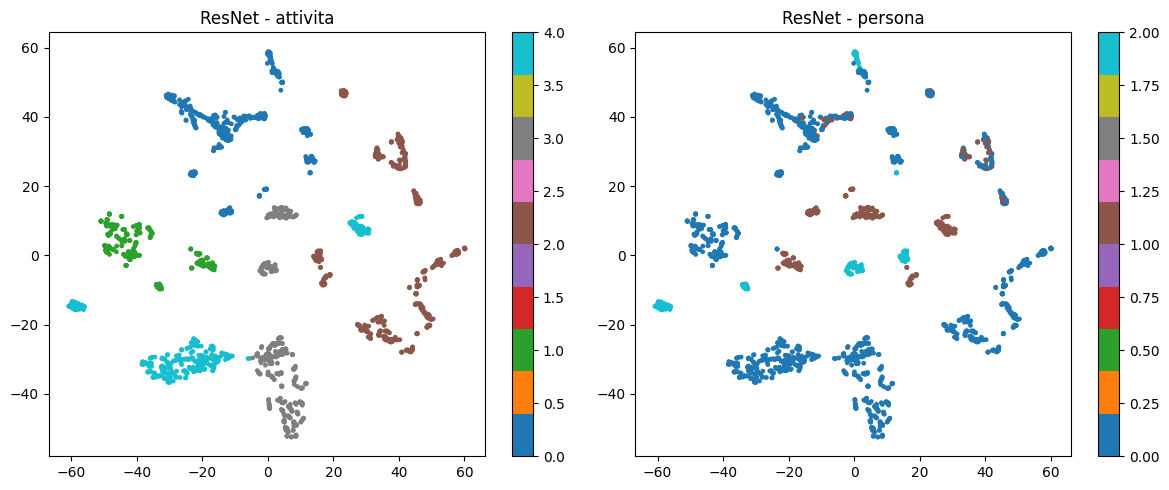

In [23]:
# =====================================================================================
#  t-SNE degli embedding della backbone (colorati per ATTIVITA e per PERSONA)
#  Mostra visivamente cosa cattura la rappresentazione condivisa.
# =====================================================================================
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt


def plot_tsne(name, model, loader, max_pts=2000):
    model.eval()
    feats, ya, yp = [], [], []
    with torch.no_grad():
        for x, a, p in loader:
            feats.append(model.encoder(x.to(device)).cpu().numpy())
            ya.append(a.numpy()); yp.append(p.numpy())
    feats = np.concatenate(feats); ya = np.concatenate(ya); yp = np.concatenate(yp)
    if len(feats) > max_pts:                            # sottocampiona per velocita'
        idx = np.random.choice(len(feats), max_pts, replace=False)
        feats, ya, yp = feats[idx], ya[idx], yp[idx]
    emb = TSNE(n_components=2, init='pca', perplexity=30).fit_transform(feats)
    fig, axs = plt.subplots(1, 2, figsize=(12, 5))
    s0 = axs[0].scatter(emb[:, 0], emb[:, 1], c=ya, cmap='tab10', s=6); axs[0].set_title(f'{name} - attivita')
    s1 = axs[1].scatter(emb[:, 0], emb[:, 1], c=yp, cmap='tab10', s=6); axs[1].set_title(f'{name} - persona')
    fig.colorbar(s0, ax=axs[0]); fig.colorbar(s1, ax=axs[1])
    plt.tight_layout(); plt.show()


plot_tsne('ResNet', res_model, test_within_loader)

# =====================================================================================
#  ABLATION CONFOUND PI (cross-day) — DA IMPOSTARE con Table 1
#  La PI puo' "barare" imparando l'ambiente invece del gait. Prova chiave: allena la PI
#  su un set di una persona e testala su un ALTRO set della STESSA persona (giorno/ambiente
#  diverso). Esempio con P1 (S1 -> S2), se Table 1 lo conferma:
#     train_p1 = make_twohead_loader([s for s in subdirs_all if set_num(s)==1], 'train', shuffle=True)
#     test_p1  = make_twohead_loader([s for s in subdirs_all if set_num(s)==2], 'test',  shuffle=False)
#  Se l'accuracy PI regge cross-day -> cattura la persona; se crolla -> catturava l'ambiente.
# =====================================================================================